In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive')

path = "/content/drive/MyDrive/Dataset/student_performance_prediction.csv"

df = pd.read_csv(path)

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
0,S00001,12.5,NaN,75.0,Yes,Master,Yes
1,S00002,9.3,95.3,60.6,No,High School,No
2,S00003,13.2,NaN,64.0,No,Associate,No
3,S00004,17.6,76.8,62.4,Yes,Bachelor,No
4,S00005,8.8,89.3,72.7,No,Master,No


In [ ]:
print(df.shape)

(40000, 7)


In [ ]:
df.describe()

,Study Hours per Week,Attendance Rate,Previous Grades
count,38005.000000,38008.000000,38006.000000
mean,9.962744,75.276323,65.440107
std,5.031154,20.393418,16.503119
min,-12.300000,-14.300000,8.300000
25%,6.600000,61.600000,55.100000
50%,10.000000,75.300000,65.200000
75%,13.400000,88.800000,75.200000
max,32.400000,150.200000,200.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 7 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Student ID                                   40000 non-null  object 
 1   Study Hours per Week                         38005 non-null  float64
 2   Attendance Rate                              38008 non-null  float64
 3   Previous Grades                              38006 non-null  float64
 4   Participation in Extracurricular Activities  38000 non-null  object 
 5   Parent Education Level                       38000 non-null  object 
 6   Passed                                       38000 non-null  object 
dtypes: float64(3), object(4)
memory usage: 2.1+ MB


In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

/tmp/ipykernel_13791/4057150236.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [ ]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_13791/2422164989.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [ ]:
print(df.isnull().sum())

Student ID                                     0
Study Hours per Week                           0
Attendance Rate                                0
Previous Grades                                0
Participation in Extracurricular Activities    0
Parent Education Level                         0
Passed                                         0
dtype: int64


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
df.to_csv("cleaned_student_data.csv", index=False)

In [ ]:
df.head()

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed
0,0,12.5,75.276323,75.0,1,4,1
1,1,9.3,95.300000,60.6,0,3,0
2,2,13.2,75.276323,64.0,0,0,0
3,3,17.6,76.800000,62.4,1,1,0
4,4,8.8,89.300000,72.7,0,4,0


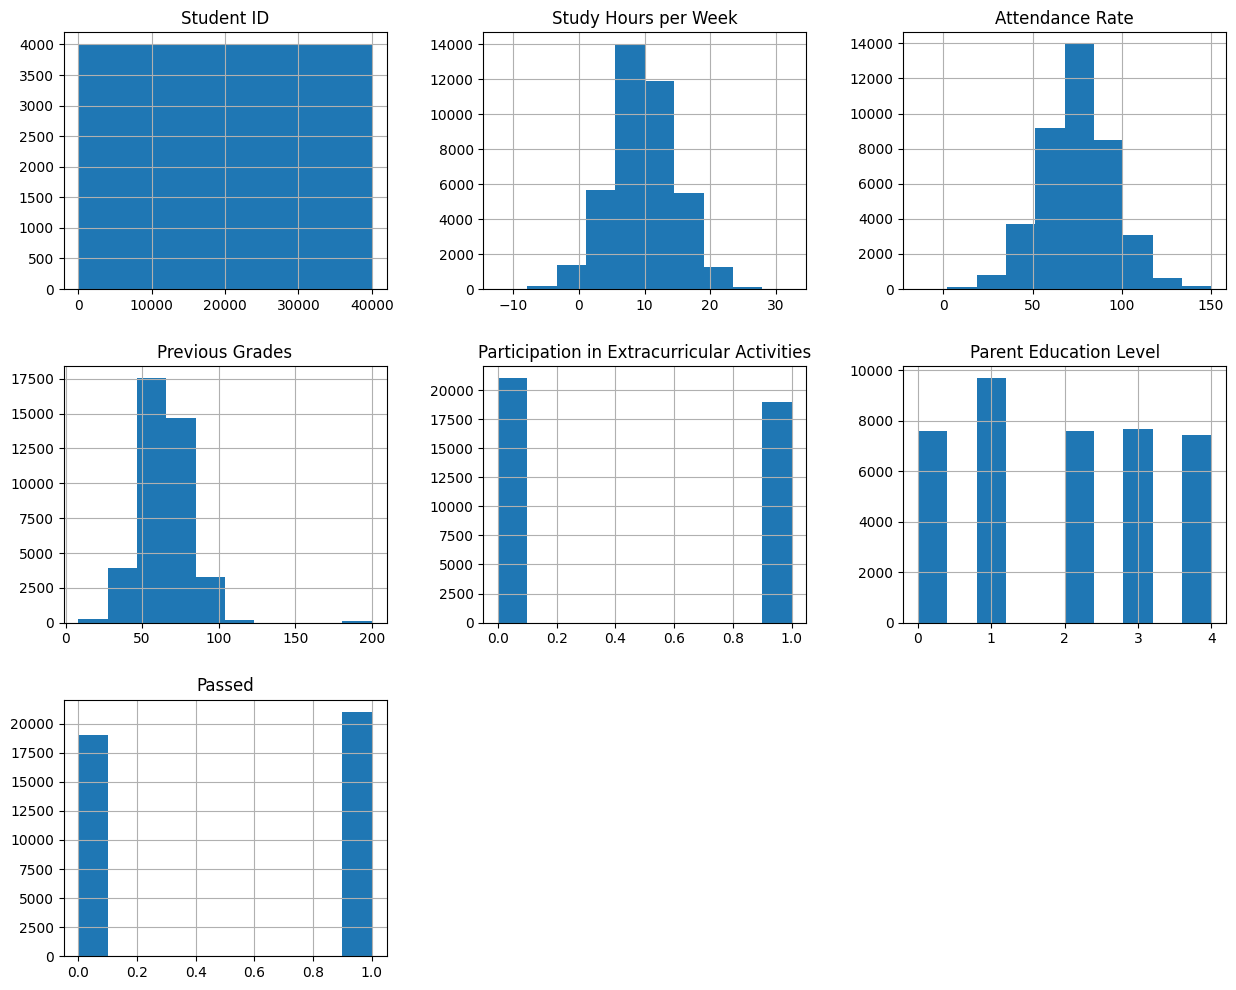

In [ ]:
df.hist(figsize=(15,12))

plt.show()

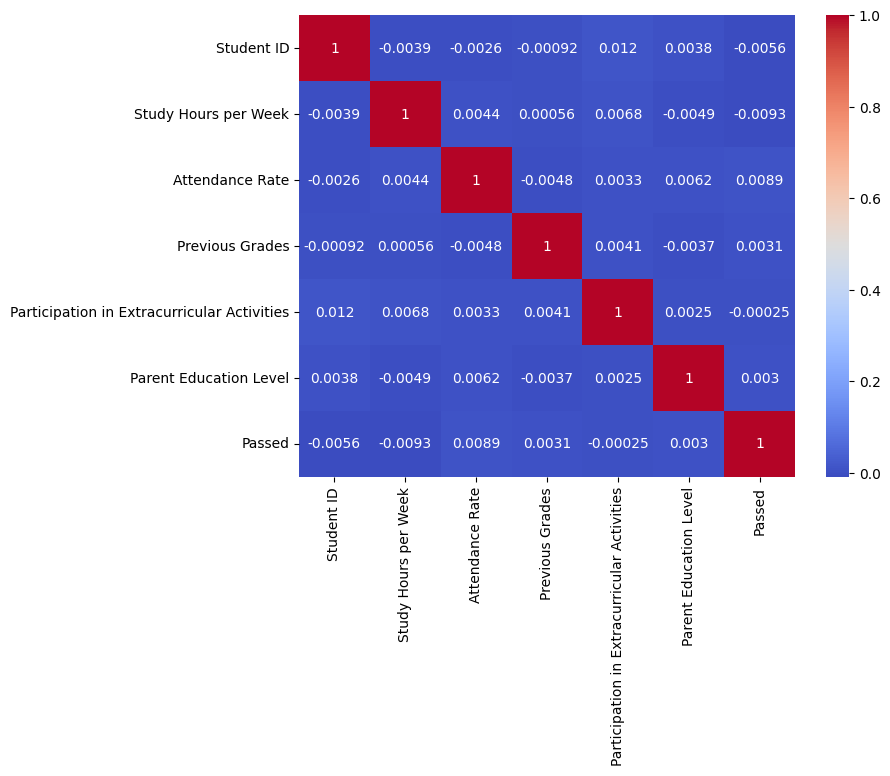

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

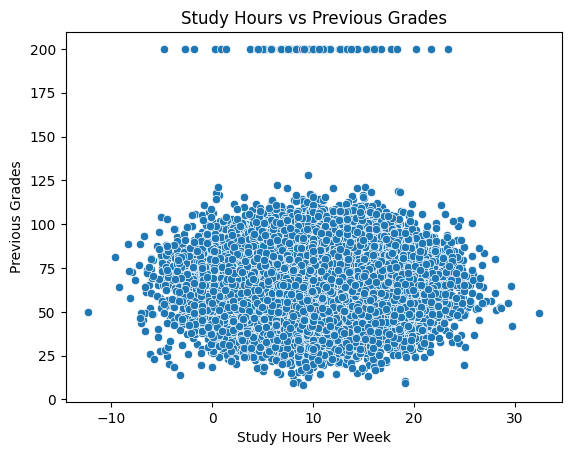

In [ ]:
sns.scatterplot(
    x=df['Study Hours per Week'],
    y=df['Previous Grades']
)

plt.xlabel("Study Hours Per Week")

plt.ylabel("Previous Grades")

plt.title("Study Hours vs Previous Grades")

plt.show()


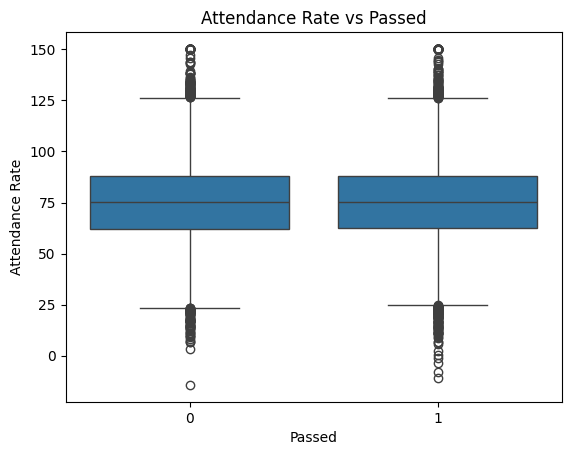

In [ ]:
sns.boxplot(
    x=df['Passed'],
    y=df['Attendance Rate']
)

plt.xlabel("Passed")

plt.ylabel("Attendance Rate")

plt.title("Attendance Rate vs Passed")

plt.show()

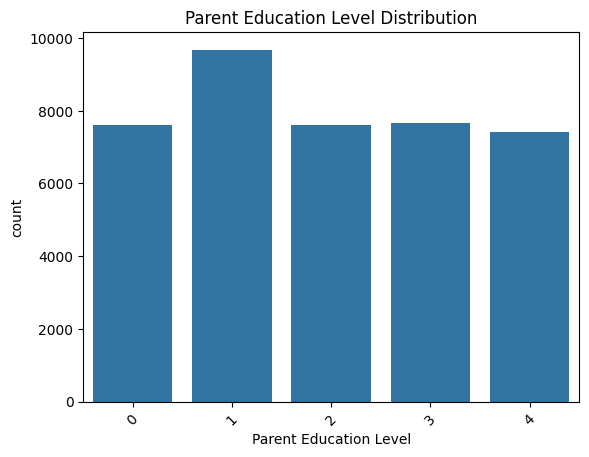

In [ ]:
sns.countplot(
    x=df['Parent Education Level']
)

plt.xticks(rotation=45)

plt.title("Parent Education Level Distribution")

plt.show()

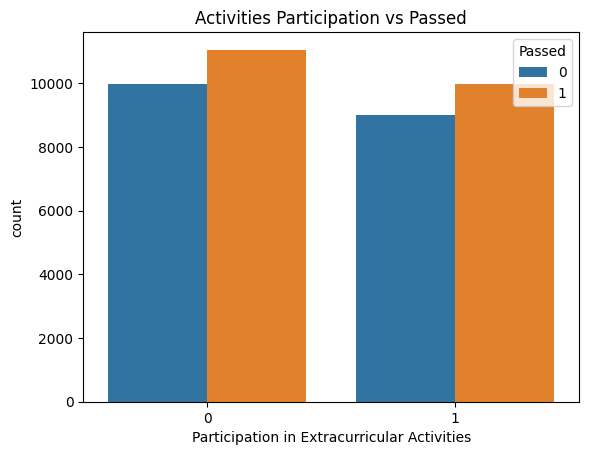

In [ ]:
sns.countplot(
    x='Participation in Extracurricular Activities',
    hue='Passed',
    data=df
)

plt.title("Activities Participation vs Passed")
plt.show()

In [ ]:
print(df['Passed'].value_counts())

Passed
1    21011
0    18989
Name: count, dtype: int64


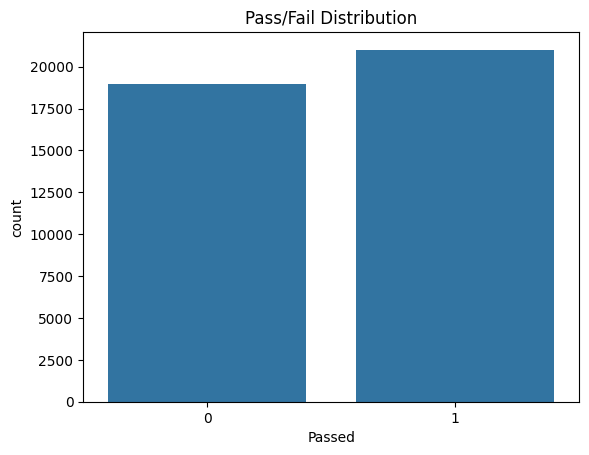

In [ ]:
sns.countplot(
    x=df['Passed']
)

plt.title("Pass/Fail Distribution")

plt.show()

In [ ]:
df['Study Attendance Score'] = (
    df['Study Hours per Week'] *
    df['Attendance Rate']
)

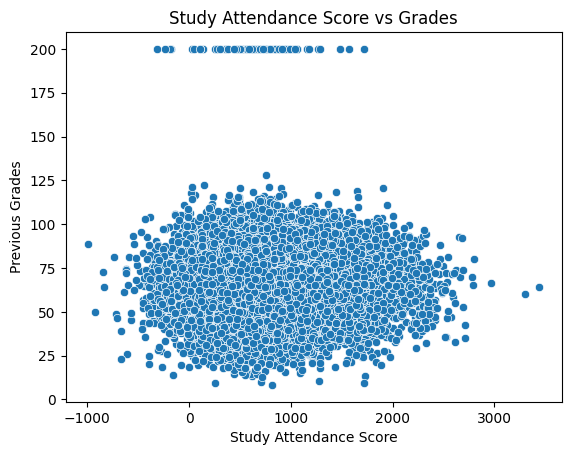

In [ ]:
sns.scatterplot(
    x=df['Study Attendance Score'],
    y=df['Previous Grades']
)

plt.title("Study Attendance Score vs Grades")

plt.show()

In [ ]:
import numpy as np

df['Future Grade'] = (
    df['Previous Grades']
    + (df['Study Hours per Week'] * 0.8)
    + (df['Attendance Rate'] * 0.2)
    + np.random.normal(0, 5, len(df))
)

In [ ]:
X = df.drop(
    ['Student ID', 'Future Grade'],
    axis=1
)

y = df['Future Grade']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
lr_pred = lr.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

rmse_lr = np.sqrt(
    mean_squared_error(y_test, lr_pred)
)

r2_lr = r2_score(y_test, lr_pred)

print("Linear Regression RMSE:", rmse_lr)

print("Linear Regression R2 Score:", r2_lr)

Linear Regression RMSE: 5.005952691832763
Linear Regression R2 Score: 0.9253363006147912


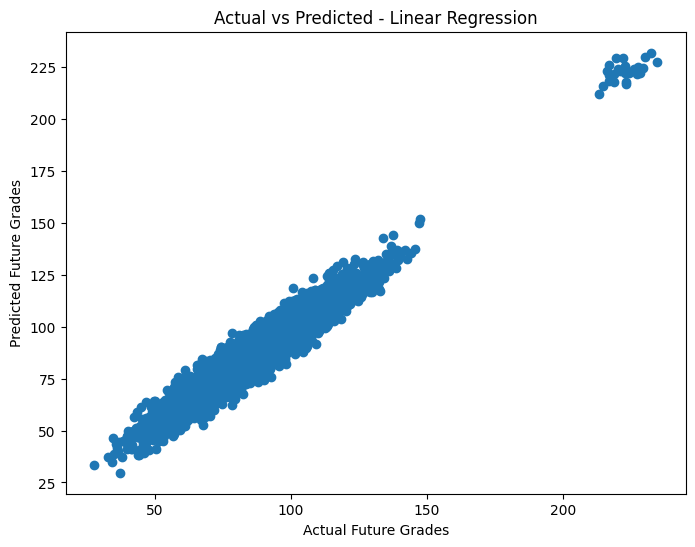

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, lr_pred)

plt.xlabel("Actual Future Grades")

plt.ylabel("Predicted Future Grades")

plt.title("Actual vs Predicted - Linear Regression")

plt.show()

In [ ]:
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': lr_pred
})

print(comparison_df.head(20))

        Actual   Predicted
0    75.967817   70.909465
1   101.076089   94.326100
2    95.081325  100.464125
3    76.421843   79.022264
4   121.375739  119.422852
5    86.960635   82.851242
6   101.067648  100.900444
7   112.712447  112.754239
8    79.128246   81.221639
9    83.066041   86.135080
10  104.444033   90.331387
11   80.856856   75.231615
12   90.920696   95.423344
13   66.240857   56.433381
14   42.847981   51.030749
15  101.526132  103.868994
16   91.884460   86.085892
17   89.990419  102.042716
18   98.180854   99.462985
19   75.273834   80.770521


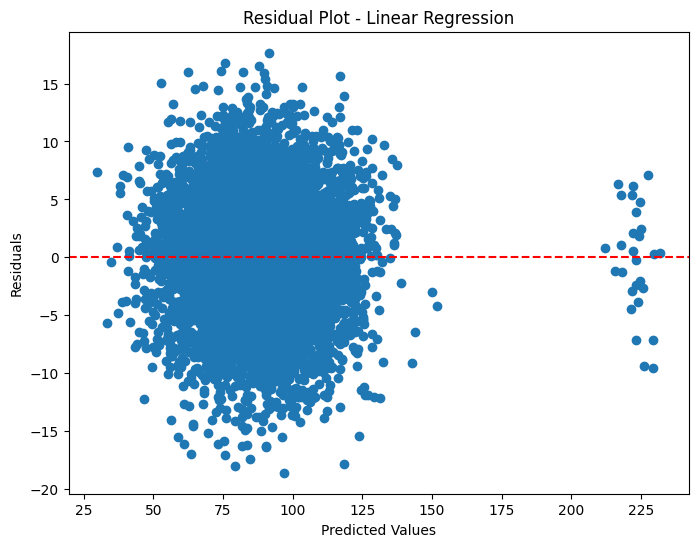

In [ ]:
residuals = y_test - lr_pred

plt.figure(figsize=(8,6))

plt.scatter(lr_pred, residuals)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("Residual Plot - Linear Regression")

plt.show()

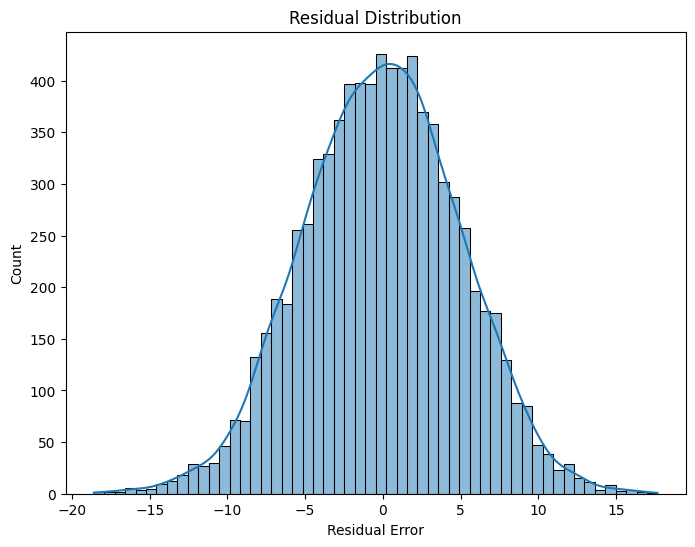

In [ ]:
plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.xlabel("Residual Error")

plt.show()

In [ ]:
X = df.drop(
    ['Student ID', 'Passed', 'Future Grade'],
    axis=1
)

y = df['Passed']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()

log_model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression()

In [ ]:
log_pred = log_model.predict(
    X_test_scaled
)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print(
    "Accuracy:",
    accuracy_score(y_test, log_pred)
)

print(
    "Precision:",
    precision_score(y_test, log_pred)
)

print(
    "Recall:",
    recall_score(y_test, log_pred)
)

print(
    "F1 Score:",
    f1_score(y_test, log_pred)
)

Accuracy: 0.5265
Precision: 0.5262826961770624
Recall: 0.9950071326676176
F1 Score: 0.6884355979601908


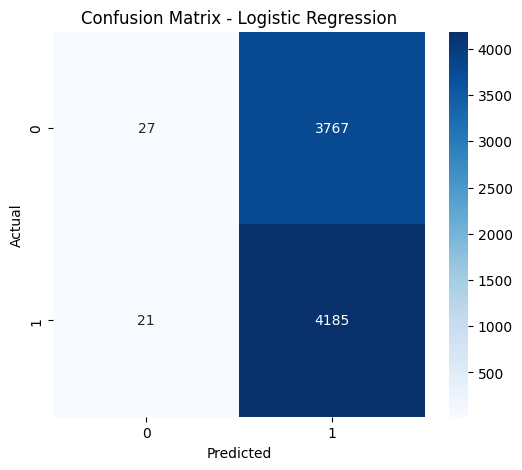

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    log_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [ ]:
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': log_pred
})

print(comparison_df.head(50))

    Actual  Predicted
0        1          1
1        1          1
2        1          1
3        0          1
4        0          1
5        1          1
6        0          1
7        0          1
8        1          1
9        1          1
10       1          1
11       0          1
12       1          1
13       1          1
14       0          1
15       0          1
16       1          1
17       1          1
18       0          1
19       1          1
20       0          1
21       0          1
22       1          1
23       0          1
24       1          1
25       1          1
26       0          1
27       1          1
28       1          1
29       1          1
30       0          1
31       1          1
32       1          1
33       0          1
34       1          1
35       0          0
36       1          1
37       1          1
38       1          1
39       1          1
40       1          1
41       1          1
42       1          1
43       0          1
44       1

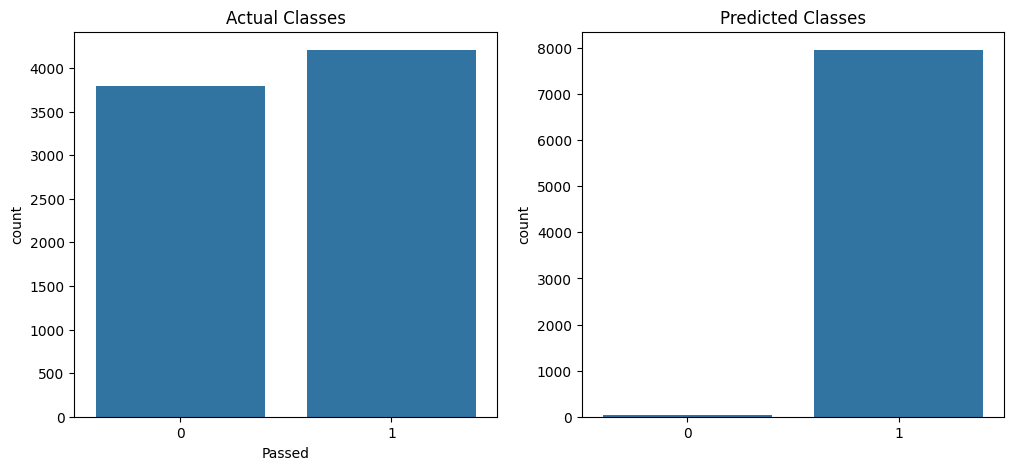

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.countplot(
    x=y_test,
    ax=axes[0]
)

axes[0].set_title("Actual Classes")

sns.countplot(
    x=log_pred,
    ax=axes[1]
)

axes[1].set_title("Predicted Classes")

plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

X_reg = df.drop(
    ['Student ID', 'Future Grade', 'Passed'],
    axis=1
)

y_reg = df['Future Grade']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)

X_test_reg_scaled = scaler_reg.transform(X_test_reg)

lr = LinearRegression()

lr.fit(X_train_reg_scaled, y_train_reg)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [ ]:
from sklearn.linear_model import LogisticRegression

X_clf = df.drop(
    ['Student ID', 'Passed', 'Future Grade'],
    axis=1
)

y_clf = df['Passed']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42
)

scaler_clf = StandardScaler()

X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)

X_test_clf_scaled = scaler_clf.transform(X_test_clf)

log_model = LogisticRegression()

log_model.fit(
    X_train_clf_scaled,
    y_train_clf
)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [ ]:
import pandas as pd

study_hours = float(input("Enter Study Hours Per Week: "))
attendance = float(input("Enter Attendance Rate: "))
previous_grades = float(input("Enter Previous Grades: "))
activities = int(input("Participation in Extracurricular Activities (0 = No, 1 = Yes): "))
parent_education = int(input("Parent Education Level (0-4): "))

study_attendance_score = study_hours * attendance

sample = pd.DataFrame({
    'Study Hours per Week': [study_hours],
    'Attendance Rate': [attendance],
    'Previous Grades': [previous_grades],
    'Participation in Extracurricular Activities': [activities],
    'Parent Education Level': [parent_education],
    'Study Attendance Score': [study_attendance_score]
})

sample_reg_scaled = scaler_reg.transform(sample)
sample_clf_scaled = scaler_clf.transform(sample)

future_grade = lr.predict(sample_reg_scaled)

pass_prediction = log_model.predict(sample_clf_scaled)

pass_probability = log_model.predict_proba(sample_clf_scaled)

print("\n========== STUDENT PERFORMANCE REPORT ==========")

print(
    f"Predicted Future Grade: {future_grade[0]:.2f}"
)

if pass_prediction[0] == 1:
    print("Predicted Result: PASS")
else:
    print("Predicted Result: FAIL")

print(
    f"Probability of Passing: {pass_probability[0][1] * 100:.2f}%"
)

print("\n========== RECOMMENDATIONS ==========")

if study_hours < 5:
    print("• Increase study hours.")

if attendance < 75:
    print("• Improve attendance.")

if previous_grades < 50:
    print("• Academic mentoring is recommended.")

if future_grade[0] < 60:
    print("• Additional learning support may be required.")

if attendance >= 85 and study_hours >= 8:
    print("• Excellent study habits. Keep it up!")

if (
    study_hours >= 8 and
    attendance >= 80 and
    previous_grades >= 70
):
    print("• Student is likely to maintain strong academic performance.")

Enter Study Hours Per Week: 15
Enter Attendance Rate: 90
Enter Previous Grades: 95
Participation in Extracurricular Activities (0 = No, 1 = Yes): 1
Parent Education Level (0-4): 4

========== STUDENT PERFORMANCE REPORT ==========
Predicted Future Grade: 125.08
Predicted Result: PASS
Probability of Passing: 53.08%

========== RECOMMENDATIONS ==========
• Excellent study habits. Keep it up!
• Student is likely to maintain strong academic performance.
